In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

In [2]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for file in filenames:
        if file == "clean_metadata.csv":
            print(os.path.join(dirname, file))

/kaggle/input/notebooks/sumedhabhadauria/01-dataset-preparation/clean_metadata.csv


In [3]:
CSV_PATH = "/kaggle/input/notebooks/sumedhabhadauria/01-dataset-preparation/clean_metadata.csv"
IMAGE_FOLDER = Path("/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images")

In [4]:
# Loading Clean Metadata

df = pd.read_csv(CSV_PATH)
print("Dataset Shape :", df.shape)
df.head()

Dataset Shape : (44419, 11)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011,Casual,Turtle Check Men Navy Blue Shirt,/kaggle/input/datasets/paramaggarwal/fashion-p...
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012,Casual,Peter England Men Party Blue Jeans,/kaggle/input/datasets/paramaggarwal/fashion-p...
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016,Casual,Titan Women Silver Watch,/kaggle/input/datasets/paramaggarwal/fashion-p...
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011,Casual,Manchester United Men Solid Black Track Pants,/kaggle/input/datasets/paramaggarwal/fashion-p...
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012,Casual,Puma Men Grey T-shirt,/kaggle/input/datasets/paramaggarwal/fashion-p...


In [5]:
#Dataset Overview

print(f"Total Products      : {len(df)}")
print(f"Master Categories   : {df['masterCategory'].nunique()}")
print(f"Sub Categories      : {df['subCategory'].nunique()}")
print(f"Article Types       : {df['articleType'].nunique()}")
print(f"Colours             : {df['baseColour'].nunique()}")

Total Products      : 44419
Master Categories   : 7
Sub Categories      : 45
Article Types       : 142
Colours             : 47


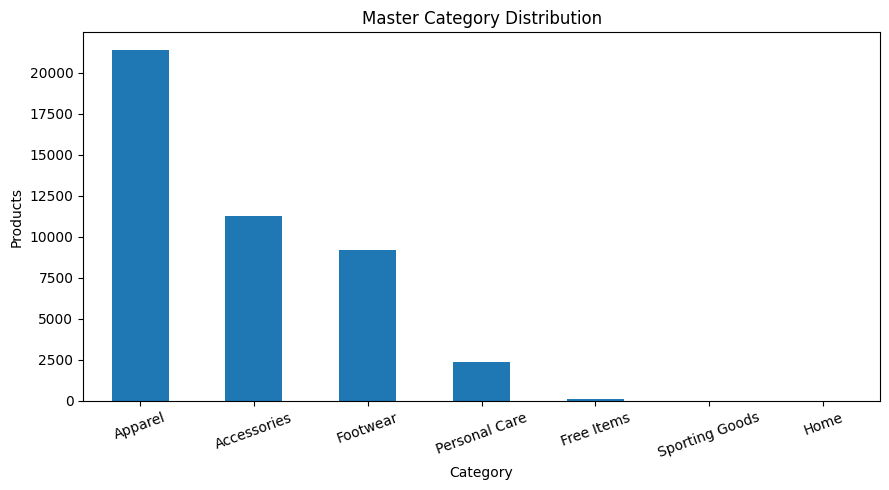

In [6]:
# Master Category distribution

master_counts = df["masterCategory"].value_counts()
plt.figure(figsize=(9,5))
master_counts.plot(kind="bar")
plt.title("Master Category Distribution")
plt.xlabel("Category")
plt.ylabel("Products")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

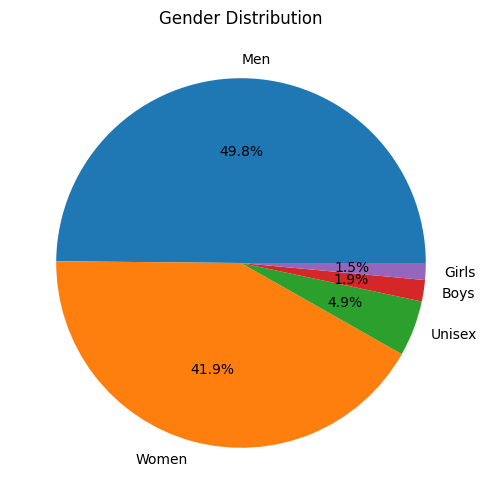

In [7]:
# Gender Distribution

gender_counts = df["gender"].value_counts()
plt.figure(figsize=(6,6))

gender_counts.plot(
    kind="pie",
    autopct="%1.1f%%")
plt.ylabel("")
plt.title("Gender Distribution")
plt.show()

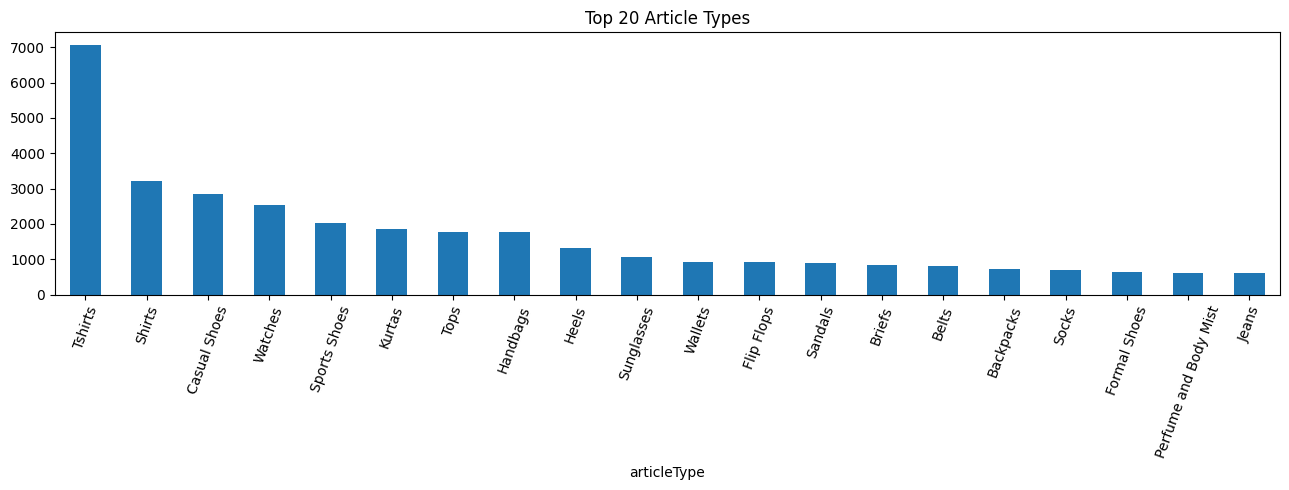

In [8]:
# Top Article types

article_counts = df["articleType"].value_counts().head(20)
plt.figure(figsize=(13,5))
article_counts.plot(kind="bar")
plt.title("Top 20 Article Types")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

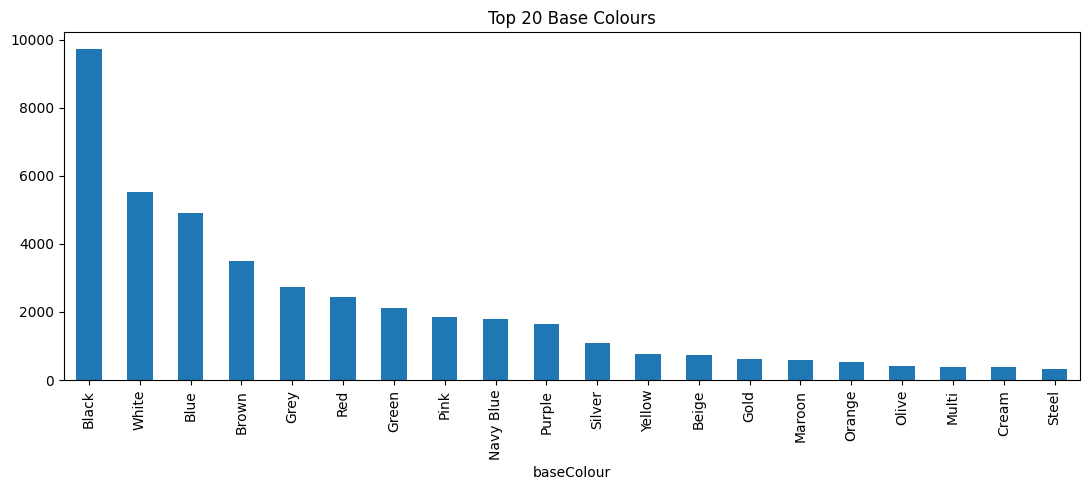

In [9]:
# Top Base Colours

colour_counts = df["baseColour"].value_counts().head(20)
plt.figure(figsize=(11,5))
colour_counts.plot(kind="bar")
plt.title("Top 20 Base Colours")
plt.tight_layout()
plt.show()

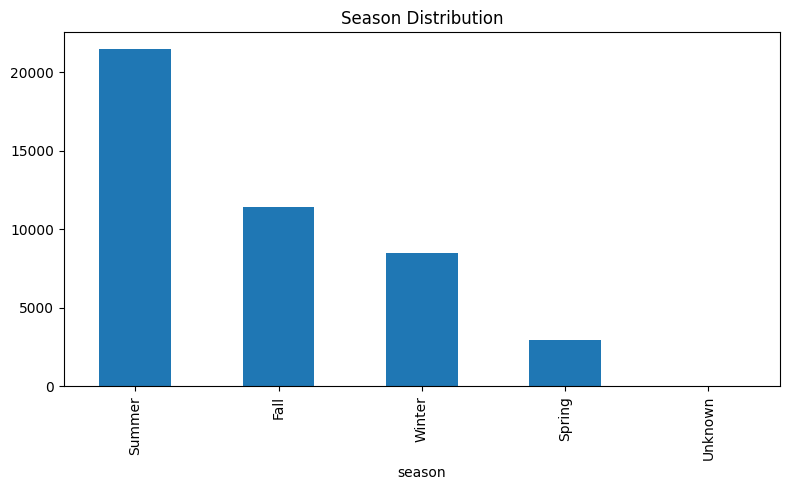

In [10]:
# Season Distribution

season_counts = df["season"].value_counts()
plt.figure(figsize=(8,5))
season_counts.plot(kind="bar")
plt.title("Season Distribution")
plt.tight_layout()
plt.show()

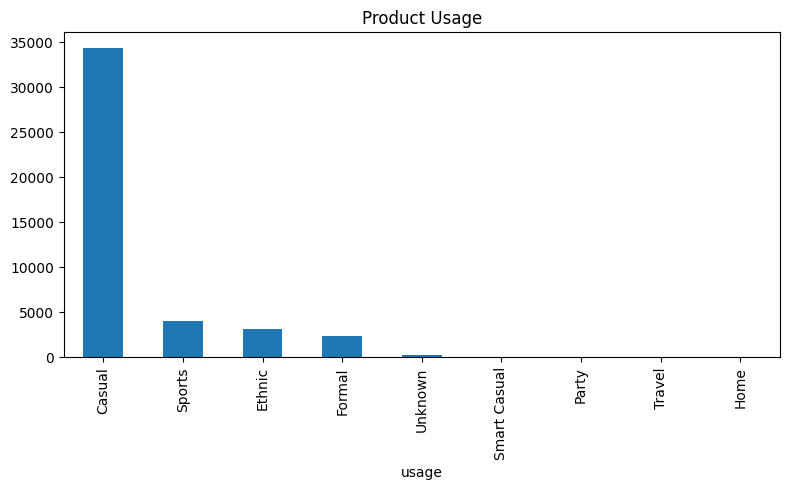

In [11]:
# Usage Distribution

usage_counts = df["usage"].value_counts()
plt.figure(figsize=(8,5))
usage_counts.plot(kind="bar")
plt.title("Product Usage")
plt.tight_layout()
plt.show()

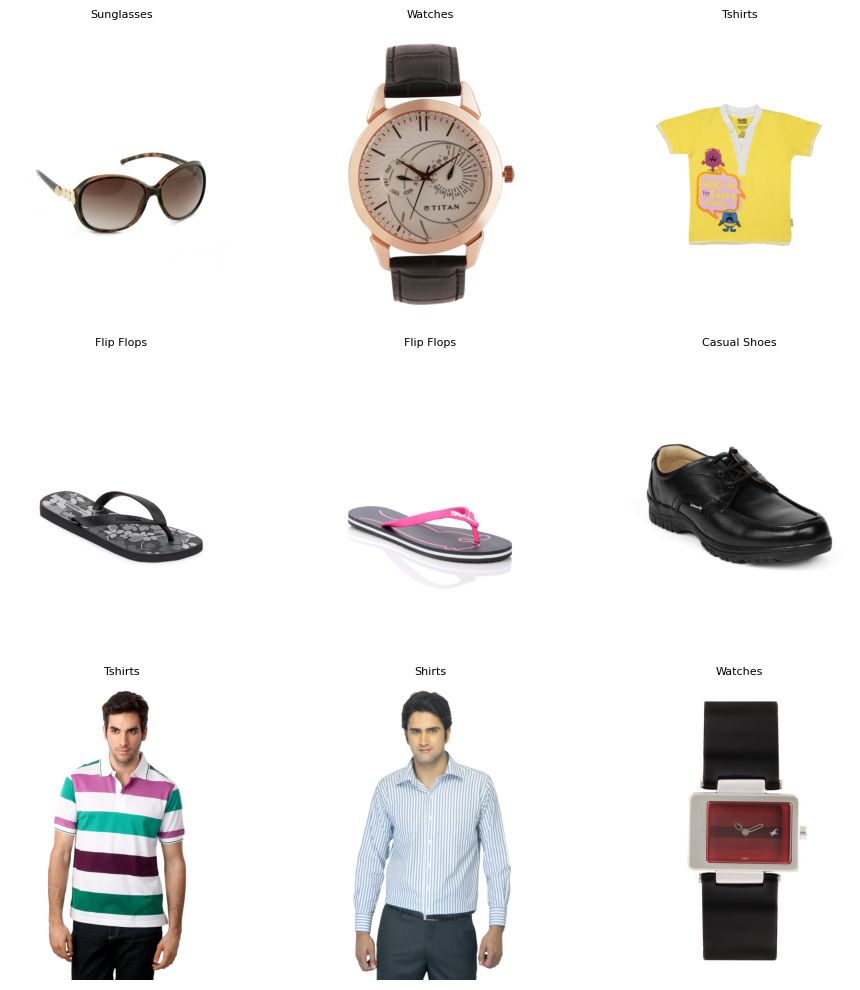

In [12]:
# Sample Products

sample = df.sample(9, random_state=42)
fig, axes = plt.subplots(3,3, figsize=(10,10))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    image_path = IMAGE_FOLDER / f"{row['id']}.jpg"
    if image_path.exists():
        img = plt.imread(image_path)
        ax.imshow(img)
        ax.set_title(row["articleType"], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [13]:
print("Key Insights")
print(f"Most Common Category : {df['masterCategory'].mode()[0]}")
print(f"Most Common Article  : {df['articleType'].mode()[0]}")
print(f"Most Common Colour   : {df['baseColour'].mode()[0]}")
print(f"Most Common Gender   : {df['gender'].mode()[0]}")

Key Insights
Most Common Category : Apparel
Most Common Article  : Tshirts
Most Common Colour   : Black
Most Common Gender   : Men
